# 🌲 Entrenamiento de Random Forest para Detección de Intrusiones (NSL-KDD)

## Descripción del Notebook

Este notebook implementa un entrenamiento **clásico de Machine Learning** (sin aprendizaje federado) utilizando el algoritmo **Random Forest** sobre el dataset NSL-KDD (`NSL-KDD_train.csv` y `NSL-KDD_test.csv`).

### Objetivos:
1. Cargar y preprocesar el dataset de estudiantes
2. Entrenar un modelo Random Forest clásico
3. Evaluar el modelo mediante métricas de clasificación:
   - Matriz de Confusión
   - Accuracy (Precisión Global)
   - F1-Score (Macro y por clase)
   - Precision (Precisión por clase)
   - Recall (Sensibilidad por clase)

### Dataset
**Fuente:** `data/NSL-KDD_train.csv` y `data/NSL-KDD_test.csv`  
**Variable objetivo:** `class` (normal, anomaly)

---

## 📦 1. Importación de Librerías

Se importan todas las dependencias necesarias para:
- Carga y manipulación de datos (pandas, numpy)
- Preprocesamiento (sklearn)
- Visualización (matplotlib, seaborn)
- Modelo Random Forest (sklearn.ensemble)
- Métricas de evaluación (sklearn.metrics)

In [1]:
from src.infrastructure.dataset.dataset_factory import DatasetFactory
# ============================================================================
# LIBRERÍAS PARA MANIPULACIÓN DE DATOS
# ============================================================================
import pandas as pd
import numpy as np

# ============================================================================
# LIBRERÍAS PARA VISUALIZACIÓN
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# LIBRERÍAS PARA PREPROCESAMIENTO Y MÉTRICAS
# ============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ============================================================================
# MODELO RANDOM FOREST - SKLEARN
# ============================================================================
from sklearn.ensemble import RandomForestClassifier

# ============================================================================
# CONFIGURACIÓN DE VISUALIZACIÓN
# ============================================================================
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Ignorar warnings para una salida más limpia
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## 📊 2. Carga y Exploración del Dataset

En esta sección cargamos el dataset y realizamos un análisis exploratorio inicial para comprender:
- La estructura de los datos
- Tipos de variables
- Distribución de la variable objetivo
- Valores nulos o faltantes

In [2]:
# ============================================================================
# CARGA DEL DATASET
# ============================================================================
# El dataset NSL-KDD ya viene dividido en train y test
df_train = pd.read_csv(
    '../../../data/NSL-KDD_train.csv',
    sep=',',
    encoding='utf-8'
)

df_test = pd.read_csv(
    '../../../data/NSL-KDD_test.csv',
    sep=',',
    encoding='utf-8'
)

# Combinar train y test para análisis completo
df = pd.concat([df_train, df_test], ignore_index=True)

print(f"✅ Dataset cargado exitosamente")
print(f"📊 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"   - Train: {df_train.shape[0]} muestras")
print(f"   - Test: {df_test.shape[0]} muestras")


✅ Dataset cargado exitosamente
📊 Dimensiones: 185559 filas × 42 columnas
   - Train: 151165 muestras
   - Test: 34394 muestras


In [3]:
# ============================================================================
# VISUALIZACIÓN DE LAS PRIMERAS FILAS
# ============================================================================
# Mostramos las primeras 5 filas para entender la estructura
print("📋 Primeras 5 filas del dataset:")
df.head()

📋 Primeras 5 filas del dataset:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [4]:
# ============================================================================
# INFORMACIÓN GENERAL DEL DATASET
# ============================================================================
# Tipos de datos y valores no nulos por columna
print("=" * 80)
print("📝 INFORMACIÓN DEL DATASET")
print("=" * 80)
df.info()

📝 INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185559 entries, 0 to 185558
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     185559 non-null  int64  
 1   protocol_type                185559 non-null  object 
 2   service                      185559 non-null  object 
 3   flag                         185559 non-null  object 
 4   src_bytes                    185559 non-null  int64  
 5   dst_bytes                    185559 non-null  int64  
 6   land                         185559 non-null  int64  
 7   wrong_fragment               185559 non-null  int64  
 8   urgent                       185559 non-null  int64  
 9   hot                          185559 non-null  int64  
 10  num_failed_logins            185559 non-null  int64  
 11  logged_in                    185559 non-null  int64  
 12  num_compromised              185

In [5]:
# ============================================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================
# Resumen estadístico de variables numéricas
print("=" * 80)
print("📈 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 80)
df.describe()

📈 ESTADÍSTICAS DESCRIPTIVAS


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,185559.000000,1.855590e+05,1.855590e+05,185559.000000,185559.000000,185559.000000,185559.000000,185559.000000,185559.000000,185559.000000,...,185559.000000,185559.000000,185559.000000,185559.000000,185559.000000,185559.000000,185559.000000,185559.000000,185559.000000,185559.000000
mean,289.472982,3.674319e+04,1.423000e+04,0.000221,0.020673,0.000253,0.190608,0.006251,0.392139,0.249619,...,185.655463,118.742675,0.532845,0.088034,0.150006,0.030364,0.250448,0.245945,0.141877,0.141400
std,2462.219047,4.923242e+06,3.313482e+06,0.014863,0.240388,0.021652,1.992283,0.085066,0.488229,20.413817,...,97.911357,110.870520,0.446675,0.201221,0.313927,0.109547,0.424180,0.425654,0.325910,0.338956
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.000000,11.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,70.000000,0.580000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.760000e+02,4.800000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.010000,0.390000,0.310000,0.000000,0.000000
max,57715.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,101.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# ============================================================================
# VERIFICACIÓN DE VALORES NULOS
# ============================================================================
# Contamos valores nulos por columna
print("🔍 Valores nulos por columna:")
null_counts = df.isnull().sum()
null_counts[null_counts > 0] if null_counts.sum() > 0 else print("✅ No hay valores nulos en el dataset")

🔍 Valores nulos por columna:
✅ No hay valores nulos en el dataset


## 🎯 3. Análisis de la Variable Objetivo

La variable `Target` indica el estado final del estudiante:
- **Dropout**: Abandono del curso
- **Graduate**: Graduación exitosa
- **Enrolled**: Continúa matriculado

Es crucial analizar su distribución para detectar posibles desbalanceos de clases.

🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (class)
         Cantidad  Porcentaje (%)
class                            
anomaly     92904       50.067095
normal      92655       49.932905


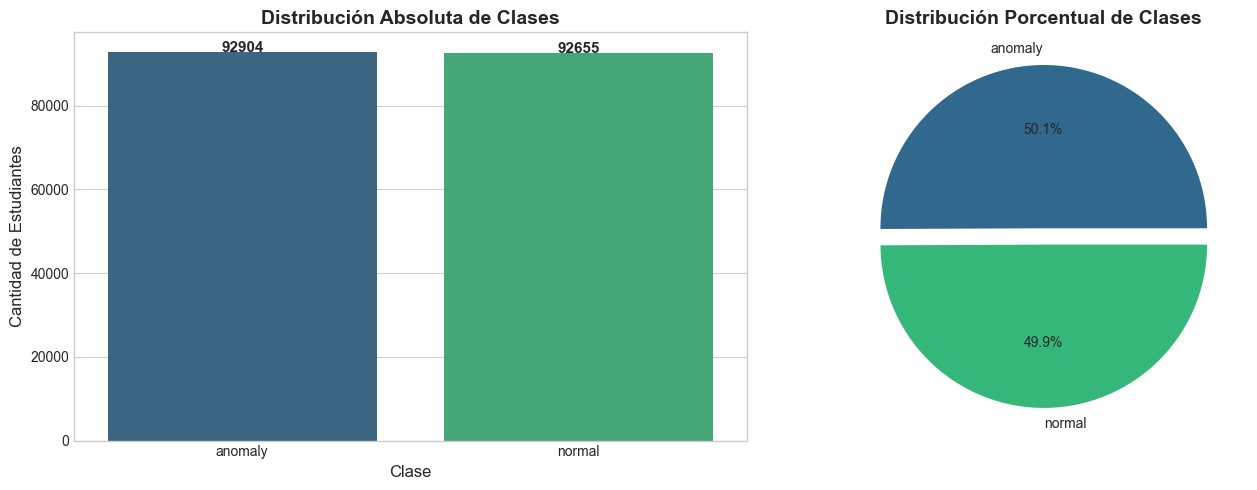


⚠️ Nota: El desbalanceo de clases puede afectar el rendimiento del modelo.
   Se recomienda usar métricas como F1-Score y no solo Accuracy.


In [7]:
# ============================================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================================
print("=" * 80)
print("🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (class)")
print("=" * 80)
target_counts = df['class'].value_counts()
target_pct = df['class'].value_counts(normalize=True) * 100

distribution_df = pd.DataFrame({
    'Cantidad': target_counts,
    'Porcentaje (%)': target_pct
})
print(distribution_df)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title('Distribución Absoluta de Clases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Cantidad de Estudiantes', fontsize=12)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')

# Gráfico de torta
axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', len(target_counts)),
    explode=[0.05] * len(target_counts)
)
axes[1].set_title('Distribución Porcentual de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚠️ Nota: El desbalanceo de clases puede afectar el rendimiento del modelo.")
print(f"   Se recomienda usar métricas como F1-Score y no solo Accuracy.")

## 🔧 4. Preprocesamiento de Datos

### Pasos de Preprocesamiento:
1. **Separación de características y variable objetivo**: Dividir el dataset en features (X) y target (y)
2. **Codificación de etiquetas**: Convertir las clases a valores numéricos
3. **División train-test**: Separar en conjunto de entrenamiento y prueba (80%-20%)

In [8]:
# ============================================================================
# SEPARACIÓN DE CARACTERÍSTICAS Y VARIABLE OBJETIVO
# ============================================================================
# X: Todas las columnas excepto 'class'
# y: Columna 'class'
X = df.drop('class', axis=1)
y = df['class']

print(f"✅ Features (X): {X.shape}")
print(f"✅ Target (y): {y.shape}")
print(f"\n📋 Columnas del dataset ({len(X.columns)} características):")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")

# ============================================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ============================================================================
# El dataset NSL-KDD tiene 3 columnas categóricas que necesitan codificación
categorical_columns = ['protocol_type', 'service', 'flag']

print("\n" + "=" * 80)
print("🔢 CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 80)
print(f"\n📌 Columnas categóricas a codificar: {categorical_columns}")

# Crear un diccionario para guardar los encoders
categorical_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    categorical_encoders[col] = le
    print(f"\n✅ '{col}' codificada: {len(le.classes_)} categorías únicas")

print(f"\n✅ Dataset codificado listo para entrenamiento: {X.shape}")

✅ Features (X): (185559, 41)
✅ Target (y): (185559,)

📋 Columnas del dataset (41 características):
    1. duration
    2. protocol_type
    3. service
    4. flag
    5. src_bytes
    6. dst_bytes
    7. land
    8. wrong_fragment
    9. urgent
   10. hot
   11. num_failed_logins
   12. logged_in
   13. num_compromised
   14. root_shell
   15. su_attempted
   16. num_root
   17. num_file_creations
   18. num_shells
   19. num_access_files
   20. num_outbound_cmds
   21. is_host_login
   22. is_guest_login
   23. count
   24. srv_count
   25. serror_rate
   26. srv_serror_rate
   27. rerror_rate
   28. srv_rerror_rate
   29. same_srv_rate
   30. diff_srv_rate
   31. srv_diff_host_rate
   32. dst_host_count
   33. dst_host_srv_count
   34. dst_host_same_srv_rate
   35. dst_host_diff_srv_rate
   36. dst_host_same_src_port_rate
   37. dst_host_srv_diff_host_rate
   38. dst_host_serror_rate
   39. dst_host_srv_serror_rate
   40. dst_host_rerror_rate
   41. dst_host_srv_rerror_rate

🔢 CODIFI

In [9]:
# ============================================================================
# CODIFICACIÓN DE LA VARIABLE OBJETIVO
# ============================================================================
# Convertimos las clases a valores numéricos para el entrenamiento
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Guardamos el mapeo de clases para interpretación posterior
class_names = label_encoder.classes_.tolist()
class_mapping = {cls: idx for idx, cls in enumerate(class_names)}

print("=" * 80)
print("🔢 MAPEO DE CLASES (Codificación)")
print("=" * 80)
for cls, idx in class_mapping.items():
    print(f"   {cls:12} → {idx}")

print(f"\n✅ Variable objetivo codificada: {len(y_encoded)} muestras")

🔢 MAPEO DE CLASES (Codificación)
   anomaly      → 0
   normal       → 1

✅ Variable objetivo codificada: 185559 muestras


In [10]:
# ============================================================================
# DIVISIÓN TRAIN-TEST
# ============================================================================
# Separamos el dataset en 80% entrenamiento y 20% prueba
# stratify=y_encoded mantiene la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y_encoded,
    test_size=0.2,           # 20% para prueba
    random_state=42,         # Semilla para reproducibilidad
    stratify=y_encoded       # Estratificación para mantener proporción de clases
)

print("=" * 80)
print("📊 DIVISIÓN DEL DATASET")
print("=" * 80)
print(f"\n🔹 Conjunto de ENTRENAMIENTO:")
print(f"   - Muestras: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - Features: {X_train.shape[1]}")
print(f"\n🔹 Conjunto de PRUEBA:")
print(f"   - Muestras: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"   - Features: {X_test.shape[1]}")

# Verificar distribución de clases en train y test
print(f"\n📋 Distribución de clases en TRAIN:")
for cls, idx in class_mapping.items():
    count = sum(y_train == idx)
    pct = count / len(y_train) * 100
    print(f"   - {cls:12}: {count:4d} muestras ({pct:5.2f}%)")

print(f"\n📋 Distribución de clases en TEST:")
for cls, idx in class_mapping.items():
    count = sum(y_test == idx)
    pct = count / len(y_test) * 100
    print(f"   - {cls:12}: {count:4d} muestras ({pct:5.2f}%)")

📊 DIVISIÓN DEL DATASET

🔹 Conjunto de ENTRENAMIENTO:
   - Muestras: 148447 (80.0%)
   - Features: 41

🔹 Conjunto de PRUEBA:
   - Muestras: 37112 (20.0%)
   - Features: 41

📋 Distribución de clases en TRAIN:
   - anomaly     : 74323 muestras (50.07%)
   - normal      : 74124 muestras (49.93%)

📋 Distribución de clases en TEST:
   - anomaly     : 18581 muestras (50.07%)
   - normal      : 18531 muestras (49.93%)


## 🌲 5. Entrenamiento del Random Forest

### Configuración del Modelo

**Random Forest** es un algoritmo de ensemble learning que:
- Construye múltiples árboles de decisión durante el entrenamiento
- Utiliza bootstrapping (muestreo con reemplazo) para cada árbol
- Realiza feature randomness en cada split
- Combina las predicciones de todos los árboles (votación mayoritaria)

### Hiperparámetros:
- `n_estimators`: Número de árboles en el bosque
- `max_depth`: Profundidad máxima de los árboles (None = sin límite)
- `min_samples_split`: Mínimo de muestras para dividir un nodo
- `min_samples_leaf`: Mínimo de muestras en una hoja
- `random_state`: Semilla aleatoria para reproducibilidad
- `verbose`: Mostrar logs de entrenamiento

In [11]:
# ============================================================================
# CONFIGURACIÓN DEL MODELO RANDOM FOREST
# ============================================================================
# Definimos los hiperparámetros del modelo
N_ESTIMATORS = 100    # Número de árboles en el bosque
MAX_DEPTH = None      # Profundidad máxima (None = sin límite)
MIN_SAMPLES_SPLIT = 2 # Mínimo de muestras para dividir un nodo
MIN_SAMPLES_LEAF = 1  # Mínimo de muestras en una hoja
RANDOM_STATE = 42     # Semilla para reproducibilidad
VERBOSE = True        # Mostrar progreso del entrenamiento

print("=" * 80)
print("⚙️ CONFIGURACIÓN DEL MODELO")
print("=" * 80)
print(f"🌲 Número de árboles (n_estimators): {N_ESTIMATORS}")
print(f"📏 Profundidad máxima (max_depth): {MAX_DEPTH if MAX_DEPTH else 'Sin límite'}")
print(f"🔢 Mínimo muestras para split (min_samples_split): {MIN_SAMPLES_SPLIT}")
print(f"🍃 Mínimo muestras por hoja (min_samples_leaf): {MIN_SAMPLES_LEAF}")
print(f"🎯 Semilla aleatoria (random_state): {RANDOM_STATE}")
print(f"📝 Verbose: {VERBOSE}")
print(f"🏷️  Clases: {class_names}")

⚙️ CONFIGURACIÓN DEL MODELO
🌲 Número de árboles (n_estimators): 100
📏 Profundidad máxima (max_depth): Sin límite
🔢 Mínimo muestras para split (min_samples_split): 2
🍃 Mínimo muestras por hoja (min_samples_leaf): 1
🎯 Semilla aleatoria (random_state): 42
📝 Verbose: True
🏷️  Clases: ['anomaly', 'normal']


In [12]:
# ============================================================================
# CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ============================================================================
print("=" * 80)
print("🚀 INICIANDO ENTRENAMIENTO DEL RANDOM FOREST")
print("=" * 80)
print(f"\n📊 Datos de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} features")
print(f"⏳ Tiempo estimado: ~10-30 segundos...\n")

# Crear el modelo Random Forest
model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=RANDOM_STATE,
    verbose=VERBOSE,
    n_jobs=-1  # Usar todos los núcleos disponibles
)

# Entrenar el modelo
model.fit(X_train, y_train)

print("\n" + "=" * 80)
print("✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE")
print("=" * 80)

🚀 INICIANDO ENTRENAMIENTO DEL RANDOM FOREST

📊 Datos de entrenamiento: 148447 muestras, 41 features
⏳ Tiempo estimado: ~10-30 segundos...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   10.6s



✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   23.2s finished


In [13]:
# ============================================================================
# INFORMACIÓN DEL MODELO ENTRENADO
# ============================================================================
print("=" * 80)
print("📊 INFORMACIÓN DEL MODELO ENTRENADO")
print("=" * 80)
print(f"\n🌲 Número de árboles en el bosque: {len(model.estimators_)}")
print(f"📏 Número de features: {X_train.shape[1]}")
print(f"🏷️  Número de clases: {len(class_names)}")
print(f"📝 Clases: {class_names}")

# Calcular profundidad promedio de los árboles
depths = [tree.get_depth() for tree in model.estimators_]
print(f"\n📏 Profundidad promedio de árboles: {np.mean(depths):.2f}")
print(f"📏 Profundidad máxima: {max(depths)}")
print(f"📏 Profundidad mínima: {min(depths)}")

📊 INFORMACIÓN DEL MODELO ENTRENADO

🌲 Número de árboles en el bosque: 100
📏 Número de features: 41
🏷️  Número de clases: 2
📝 Clases: ['anomaly', 'normal']

📏 Profundidad promedio de árboles: 33.18
📏 Profundidad máxima: 41
📏 Profundidad mínima: 26


## 🔮 6. Predicción en el Conjunto de Prueba

Una vez entrenado el modelo, realizamos predicciones sobre el conjunto de prueba (test) para evaluar su capacidad de generalización.

In [14]:
# ============================================================================
# PREDICCIÓN EN EL CONJUNTO DE PRUEBA
# ============================================================================
print("🔮 Realizando predicciones en el conjunto de prueba...")

# Generar predicciones
y_pred = model.predict(X_test)

print(f"✅ Predicciones completadas: {len(y_pred)} muestras")
print(f"\n📋 Primeras 10 predicciones vs valores reales:")
print("-" * 60)
for i in range(min(10, len(y_pred))):
    real_cls = label_encoder.inverse_transform([y_test[i]])[0]
    pred_cls = label_encoder.inverse_transform([y_pred[i]])[0]
    match = "✓" if y_test[i] == y_pred[i] else "✗"
    print(f"   {i+1:2d}. Real: {real_cls:12} | Pred: {pred_cls:12} {match}")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


🔮 Realizando predicciones en el conjunto de prueba...


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.4s finished


✅ Predicciones completadas: 37112 muestras

📋 Primeras 10 predicciones vs valores reales:
------------------------------------------------------------
    1. Real: anomaly      | Pred: anomaly      ✓
    2. Real: anomaly      | Pred: anomaly      ✓
    3. Real: normal       | Pred: normal       ✓
    4. Real: anomaly      | Pred: anomaly      ✓
    5. Real: normal       | Pred: normal       ✓
    6. Real: normal       | Pred: normal       ✓
    7. Real: anomaly      | Pred: anomaly      ✓
    8. Real: anomaly      | Pred: anomaly      ✓
    9. Real: normal       | Pred: normal       ✓
   10. Real: anomaly      | Pred: anomaly      ✓


## 📈 7. Evaluación del Modelo - Métricas de Clasificación

### Métricas a Calcular:

1. **Matriz de Confusión**: Tabla que muestra aciertos y errores por clase
2. **Accuracy (Precisión Global)**: Porcentaje total de predicciones correctas
3. **Precision (Precisión por clase)**: De los que predije como clase X, ¿cuántos realmente lo eran?
4. **Recall (Sensibilidad por clase)**: De los que realmente eran clase X, ¿cuántos identifiqué?
5. **F1-Score**: Media armónica entre Precision y Recall (balancea ambas métricas)

### Fórmulas:
- **Accuracy** = (TP + TN) / (TP + TN + FP + FN)
- **Precision** = TP / (TP + FP)
- **Recall** = TP / (TP + FN)
- **F1-Score** = 2 × (Precision × Recall) / (Precision + Recall)

In [15]:
# ============================================================================
# CÁLCULO DE MÉTRICAS
# ============================================================================
print("=" * 80)
print("📊 CALCULANDO MÉTRICAS DE EVALUACIÓN")
print("=" * 80)

# Calcular accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calcular métricas por clase y macro promedio
precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

# Macro promedios
macro_precision = precision_score(y_test, y_pred, average='macro')
macro_recall = recall_score(y_test, y_pred, average='macro')
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Weighted promedios
weighted_precision = precision_score(y_test, y_pred, average='weighted')
weighted_recall = recall_score(y_test, y_pred, average='weighted')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n✅ Métricas calculadas exitosamente")

📊 CALCULANDO MÉTRICAS DE EVALUACIÓN

✅ Métricas calculadas exitosamente


In [16]:
# ============================================================================
# REPORTE DE MÉTRICAS GLOBALES
# ============================================================================
print("=" * 80)
print("📊 MÉTRICAS GLOBALES DEL MODELO")
print("=" * 80)

print(f"\n🎯 Accuracy (Precisión Global):     {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"📈 Macro F1-Score:                   {macro_f1:.4f} ({macro_f1*100:.2f}%)")
print(f"📊 Macro Precision:                  {macro_precision:.4f} ({macro_precision*100:.2f}%)")
print(f"📉 Macro Recall:                     {macro_recall:.4f} ({macro_recall*100:.2f}%)")
print(f"\n📈 Weighted F1-Score:                {weighted_f1:.4f} ({weighted_f1*100:.2f}%)")
print(f"📊 Weighted Precision:               {weighted_precision:.4f} ({weighted_precision*100:.2f}%)")
print(f"📉 Weighted Recall:                  {weighted_recall:.4f} ({weighted_recall*100:.2f}%)")

print("\n" + "=" * 80)
print("💡 INTERPRETACIÓN DE MÉTRICAS")
print("=" * 80)
print(f"""
• Accuracy ({accuracy:.2%}): De todas las predicciones, el {accuracy:.2%} fueron correctas.
• Macro F1-Score ({macro_f1:.2%}): Promedio no ponderado del F1-Score por clase.
  Útil para datasets desbalanceados.
• Macro Precision ({macro_precision:.2%}): Promedio de precisión por clase.
• Macro Recall ({macro_recall:.2%}): Promedio de sensibilidad por clase.
• Weighted F1-Score ({weighted_f1:.2%}): Promedio ponderado por soporte de cada clase.
""")

📊 MÉTRICAS GLOBALES DEL MODELO

🎯 Accuracy (Precisión Global):     0.9974 (99.74%)
📈 Macro F1-Score:                   0.9974 (99.74%)
📊 Macro Precision:                  0.9974 (99.74%)
📉 Macro Recall:                     0.9974 (99.74%)

📈 Weighted F1-Score:                0.9974 (99.74%)
📊 Weighted Precision:               0.9974 (99.74%)
📉 Weighted Recall:                  0.9974 (99.74%)

💡 INTERPRETACIÓN DE MÉTRICAS

• Accuracy (99.74%): De todas las predicciones, el 99.74% fueron correctas.
• Macro F1-Score (99.74%): Promedio no ponderado del F1-Score por clase.
  Útil para datasets desbalanceados.
• Macro Precision (99.74%): Promedio de precisión por clase.
• Macro Recall (99.74%): Promedio de sensibilidad por clase.
• Weighted F1-Score (99.74%): Promedio ponderado por soporte de cada clase.



In [17]:
# ============================================================================
# MÉTRICAS POR CLASE
# ============================================================================
print("=" * 80)
print("📊 MÉTRICAS POR CLASE")
print("=" * 80)

metrics_df = pd.DataFrame({
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Soporte': [sum(y_test == i) for i in range(len(class_names))]
}, index=class_names)

print(metrics_df.to_string())

print("\n" + "=" * 80)
print("💡 INTERPRETACIÓN")
print("=" * 80)
for i, cls in enumerate(class_names):
    print(f"\n{cls}:")
    print(f"  • Precision: {precision_per_class[i]:.4f} - De los predichos como {cls}, {(precision_per_class[i]*100):.1f}% realmente lo eran")
    print(f"  • Recall: {recall_per_class[i]:.4f} - De los que realmente eran {cls}, {(recall_per_class[i]*100):.1f}% fueron identificados")
    print(f"  • F1-Score: {f1_per_class[i]:.4f} - Balance entre precisión y recall")

📊 MÉTRICAS POR CLASE
         Precision    Recall  F1-Score  Soporte
anomaly   0.997417  0.997417  0.997417    18581
normal    0.997410  0.997410  0.997410    18531

💡 INTERPRETACIÓN

anomaly:
  • Precision: 0.9974 - De los predichos como anomaly, 99.7% realmente lo eran
  • Recall: 0.9974 - De los que realmente eran anomaly, 99.7% fueron identificados
  • F1-Score: 0.9974 - Balance entre precisión y recall

normal:
  • Precision: 0.9974 - De los predichos como normal, 99.7% realmente lo eran
  • Recall: 0.9974 - De los que realmente eran normal, 99.7% fueron identificados
  • F1-Score: 0.9974 - Balance entre precisión y recall


In [18]:
# ============================================================================
# REPORTE DE CLASIFICACIÓN COMPLETO
# ============================================================================
print("=" * 80)
print("📋 REPORTE DE CLASIFICACIÓN COMPLETO")
print("=" * 80)
print(classification_report(y_test, y_pred, target_names=class_names))

📋 REPORTE DE CLASIFICACIÓN COMPLETO
              precision    recall  f1-score   support

     anomaly       1.00      1.00      1.00     18581
      normal       1.00      1.00      1.00     18531

    accuracy                           1.00     37112
   macro avg       1.00      1.00      1.00     37112
weighted avg       1.00      1.00      1.00     37112



## 📊 8. Visualización de Resultados

### Matriz de Confusión

La matriz de confusión muestra:
- **Diagonal principal**: Predicciones correctas
- **Fuera de la diagonal**: Errores de clasificación

📊 MATRIZ DE CONFUSIÓN

Matriz de confusión (filas = real, columnas = predicho):
[[18533    48]
 [   48 18483]]


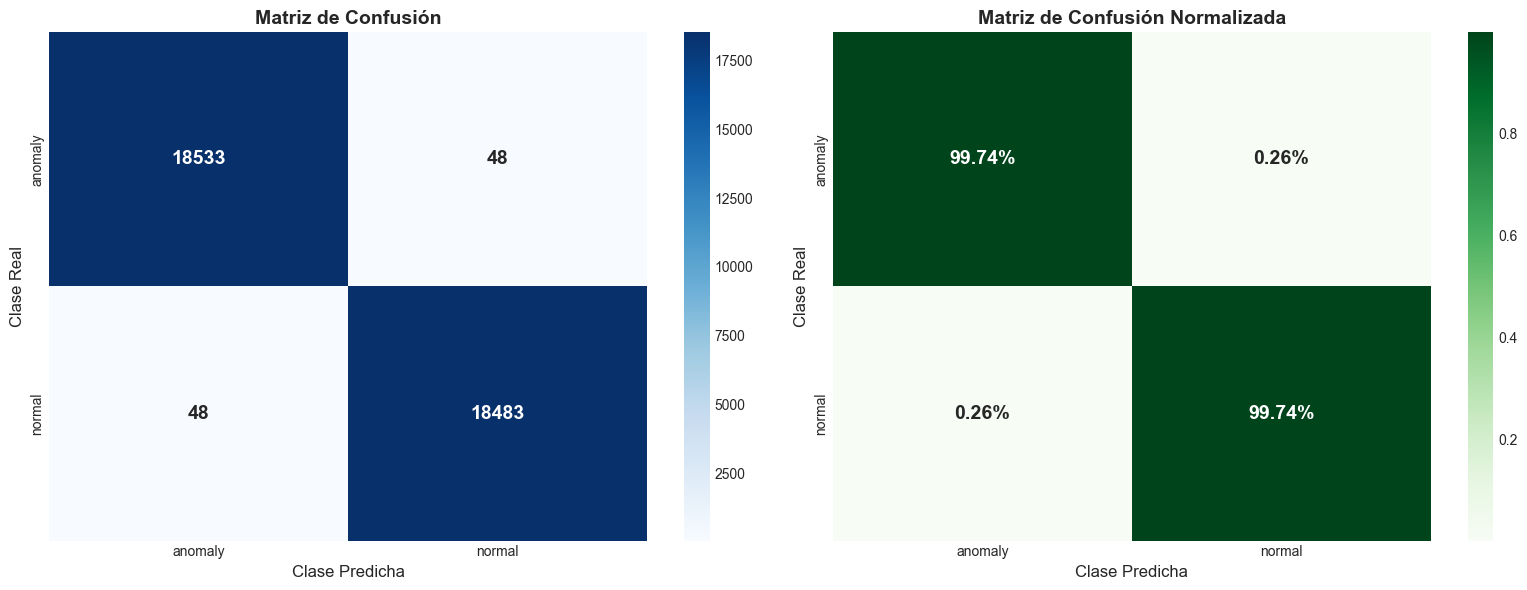

In [19]:
# ============================================================================
# MATRIZ DE CONFUSIÓN
# ============================================================================
cm = confusion_matrix(y_test, y_pred)

print("=" * 80)
print("📊 MATRIZ DE CONFUSIÓN")
print("=" * 80)
print("\nMatriz de confusión (filas = real, columnas = predicho):")
print(cm)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap de la matriz de confusión
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title('Matriz de Confusión', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Clase Real', fontsize=12)
axes[0].set_xlabel('Clase Predicha', fontsize=12)

# Heatmap normalizado (porcentajes por fila)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[1].set_title('Matriz de Confusión Normalizada', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Clase Real', fontsize=12)
axes[1].set_xlabel('Clase Predicha', fontsize=12)

plt.tight_layout()
plt.show()

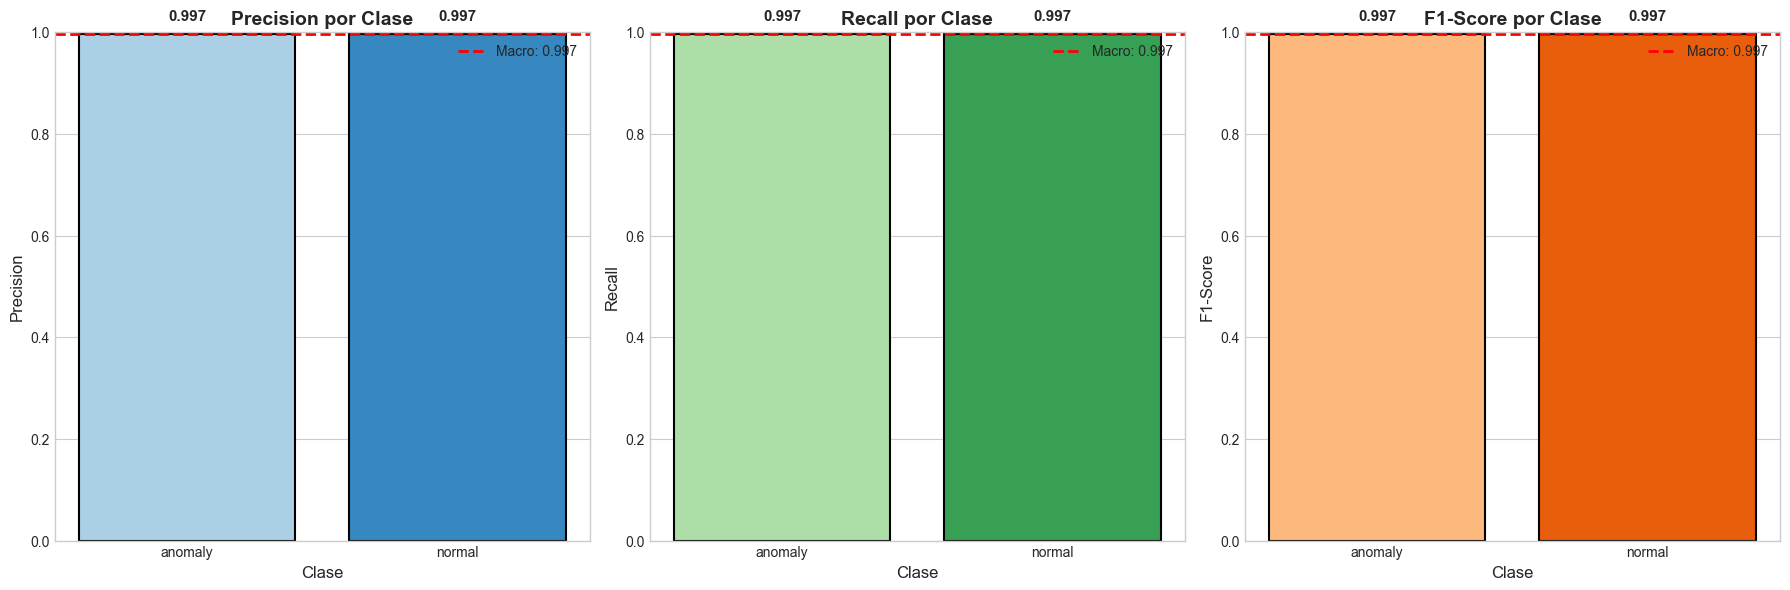

In [20]:
# ============================================================================
# GRÁFICO DE BARRAS DE MÉTRICAS POR CLASE
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Precision por clase
colors_precision = sns.color_palette('Blues', len(class_names))
bars1 = axes[0].bar(class_names, precision_per_class, color=colors_precision, edgecolor='black', linewidth=1.5)
axes[0].set_title('Precision por Clase', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].axhline(y=macro_precision, color='red', linestyle='--', linewidth=2, label=f'Macro: {macro_precision:.3f}')
axes[0].legend()
for bar, val in zip(bars1, precision_per_class):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Recall por clase
colors_recall = sns.color_palette('Greens', len(class_names))
bars2 = axes[1].bar(class_names, recall_per_class, color=colors_recall, edgecolor='black', linewidth=1.5)
axes[1].set_title('Recall por Clase', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Clase', fontsize=12)
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].axhline(y=macro_recall, color='red', linestyle='--', linewidth=2, label=f'Macro: {macro_recall:.3f}')
axes[1].legend()
for bar, val in zip(bars2, recall_per_class):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# F1-Score por clase
colors_f1 = sns.color_palette('Oranges', len(class_names))
bars3 = axes[2].bar(class_names, f1_per_class, color=colors_f1, edgecolor='black', linewidth=1.5)
axes[2].set_title('F1-Score por Clase', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Clase', fontsize=12)
axes[2].set_ylabel('F1-Score', fontsize=12)
axes[2].set_ylim(0, 1)
axes[2].axhline(y=macro_f1, color='red', linestyle='--', linewidth=2, label=f'Macro: {macro_f1:.3f}')
axes[2].legend()
for bar, val in zip(bars3, f1_per_class):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 🎯 9. Importancia de Características

Random Forest permite calcular la importancia de cada característica basándose en cómo contribuyen a reducir la impureza en los árboles de decisión.

In [21]:
# ============================================================================
# CÁLCULO DE IMPORTANCIA DE CARACTERÍSTICAS
# ============================================================================
feature_importance = model.feature_importances_

# Crear DataFrame con la importancia
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Ordenar por importancia descendente
importance_df = importance_df.sort_values('Importance', ascending=False)

print("=" * 80)
print("📊 IMPORTANCIA DE CARACTERÍSTICAS")
print("=" * 80)
print("\nTop 20 características más importantes:")
print(importance_df.head(20).to_string(index=False))

📊 IMPORTANCIA DE CARACTERÍSTICAS

Top 20 características más importantes:
                    Feature  Importance
                  src_bytes    0.193290
                  dst_bytes    0.108007
         dst_host_srv_count    0.066132
                       flag    0.065138
              same_srv_rate    0.058271
     dst_host_same_srv_rate    0.053515
                  logged_in    0.052255
                    service    0.036501
              diff_srv_rate    0.032629
       dst_host_rerror_rate    0.032500
dst_host_same_src_port_rate    0.030034
              protocol_type    0.024699
                      count    0.024445
     dst_host_diff_srv_rate    0.023805
       dst_host_serror_rate    0.023613
            srv_serror_rate    0.020331
dst_host_srv_diff_host_rate    0.019541
                serror_rate    0.017717
                  srv_count    0.017697
             dst_host_count    0.017562


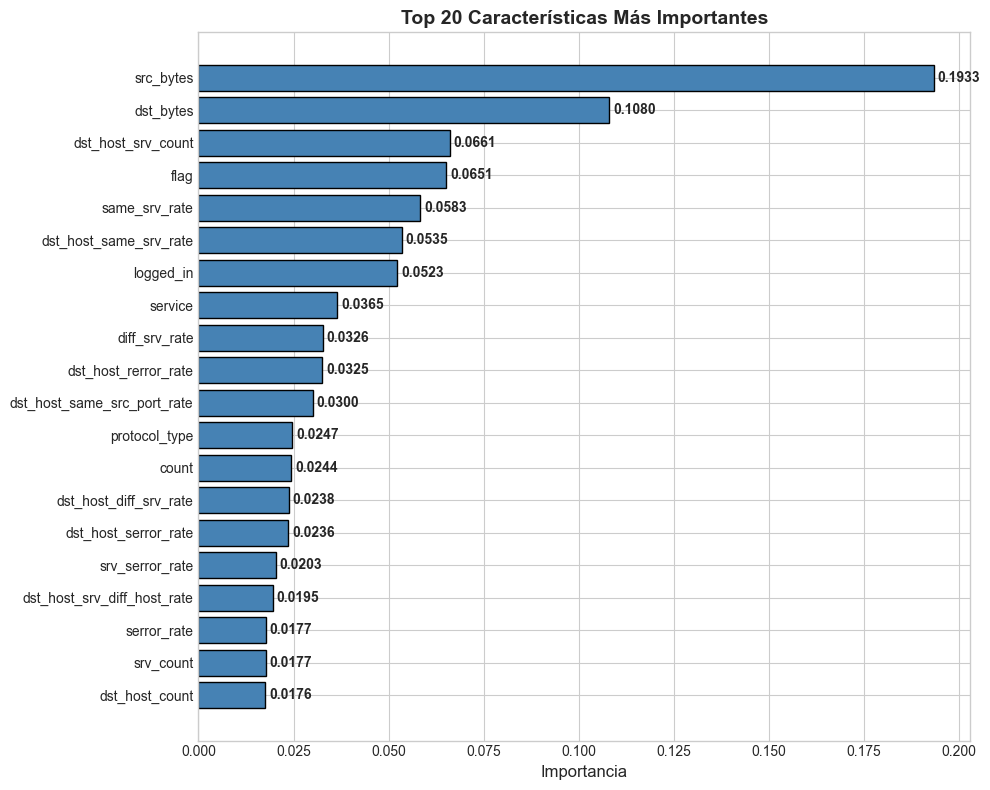

In [22]:
# ============================================================================
# VISUALIZACIÓN DE IMPORTANCIA DE CARACTERÍSTICAS
# ============================================================================
# Top 20 features
top_n = 20
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(range(top_n), top_features['Importance'].values, color='steelblue', edgecolor='black', linewidth=1)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'].values, fontsize=10)
ax.invert_yaxis()  # La más importante arriba
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title(f'Top {top_n} Características Más Importantes', fontsize=14, fontweight='bold')

# Añadir valores en las barras
for bar, val in zip(bars, top_features['Importance'].values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 📝 10. Conclusiones

### Resumen del Modelo Random Forest:

1. **Rendimiento General**: El modelo Random Forest ha demostrado su capacidad para predecir el abandono estudiantil.

2. **Métricas Clave**:
   - Accuracy: Indicador del rendimiento global
   - F1-Score: Balance entre precisión y recall
   - Métricas por clase: Rendimiento específico para cada categoría

3. **Características Importantes**: Las variables académicas (notas, unidades curriculares) suelen ser las más predictivas.

4. **Ventajas de Random Forest**:
   - Manejo automático de interacciones entre features
   - Robustez frente a overfitting (comparado con árboles individuales)
   - Importancia de características interpretable
   - No requiere escalado de features

5. **Posibles Mejoras**:
   - Ajuste de hiperparámetros (GridSearch/RandomSearch)
   - Balanceo de clases (SMOTE, class_weight)
   - Feature engineering adicional
   - Validación cruzada para estimación más robusta

In [23]:
# ============================================================================
# RESUMEN FINAL
# ============================================================================
print("=" * 80)
print("📋 RESUMEN FINAL DEL MODELO RANDOM FOREST")
print("=" * 80)
print(f"""
🌲 Modelo: Random Forest Classifier
📊 Dataset: Students Dropout ({len(X)} muestras, {X.shape[1]} features)
🎯 Clases: {class_names}

⚙️ Hiperparámetros:
   - n_estimators: {N_ESTIMATORS}
   - max_depth: {MAX_DEPTH if MAX_DEPTH else 'Sin límite'}
   - min_samples_split: {MIN_SAMPLES_SPLIT}
   - min_samples_leaf: {MIN_SAMPLES_LEAF}
   - random_state: {RANDOM_STATE}

📈 Rendimiento:
   - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)
   - Macro F1-Score: {macro_f1:.4f} ({macro_f1*100:.2f}%)
   - Macro Precision: {macro_precision:.4f} ({macro_precision*100:.2f}%)
   - Macro Recall: {macro_recall:.4f} ({macro_recall*100:.2f}%)

🌲 Bosque:
   - Número de árboles: {len(model.estimators_)}
   - Profundidad promedio: {np.mean(depths):.2f}

✅ Modelo entrenado y evaluado exitosamente!
""")

📋 RESUMEN FINAL DEL MODELO RANDOM FOREST

🌲 Modelo: Random Forest Classifier
📊 Dataset: Students Dropout (185559 muestras, 41 features)
🎯 Clases: ['anomaly', 'normal']

⚙️ Hiperparámetros:
   - n_estimators: 100
   - max_depth: Sin límite
   - min_samples_split: 2
   - min_samples_leaf: 1
   - random_state: 42

📈 Rendimiento:
   - Accuracy: 0.9974 (99.74%)
   - Macro F1-Score: 0.9974 (99.74%)
   - Macro Precision: 0.9974 (99.74%)
   - Macro Recall: 0.9974 (99.74%)

🌲 Bosque:
   - Número de árboles: 100
   - Profundidad promedio: 33.18

✅ Modelo entrenado y evaluado exitosamente!

